# Skenario 01 — Optimasi PSO untuk Random Forest dan SVR

Notebook ini memakai data, target, fitur, pembagian acak, dan ruang pencarian yang sama dengan notebook ABC. Perbedaannya hanya metode optimasi: posisi, kecepatan, personal best, dan global best mengikuti Particle Swarm Optimization (PSO).

In [1]:
from pathlib import Path
import json
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

SEED = 42
np.random.seed(SEED)

## Konfigurasi dan persiapan data

In [2]:
SENSOR_COLS = [
    "Exhaust Gas Temperature LF (Left Front)",
    "Exhaust Gas Temperature LR (Left Rear)",
    "Exhaust Gas Temperature RF (Right Front)",
    "Exhaust Gas Temperature RR (Right Rear)",
    "Blowby Pressure (Kpa)",
    "Boost Pressure (Kpa)",
    "Engine Oil Temp (°C)",
    "Coolant Temp (°C)",
]
LIFE_COL = "Unit Lifetime (Hour)"
STATUS_COL = "Status"
TARGET_COL = "sisa jam"
FEATURE_COLS = SENSOR_COLS.copy()

cfg = {
    "data_file": "datas/Data_PT.Amanah_Critical_Break.xlsx",
    "max_rul": 2550.0,
    "test_size": 0.20,
    "cv_folds": 5,
    "swarm_size": 20,
    "iterations": 30,
    "patience": 8,
    "inertia": 0.7,
    "cognitive": 1.5,
    "social": 1.5,
}
RF_KEYS = ["n_estimators", "max_depth", "min_samples_split", "min_samples_leaf", "max_features"]
RF_BOUNDS = np.array([[50, 300], [2, 30], [2, 20], [1, 10], [0.1, 1.0]], dtype=float)
SVR_KEYS = ["C", "epsilon", "gamma"]
SVR_BOUNDS = np.array([[0.1, 1000], [0.001, 50], [0.0001, 1]], dtype=float)

def find_root():
    for path in [Path.cwd(), *Path.cwd().parents]:
        if (path / cfg["data_file"]).exists():
            return path
    raise FileNotFoundError(f"Dataset tidak ditemukan: {cfg['data_file']}")

def prepare_data(root):
    raw = pd.read_excel(root / cfg["data_file"])
    data = raw[[*FEATURE_COLS, LIFE_COL, STATUS_COL]].copy()
    for col in FEATURE_COLS:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    data[LIFE_COL] = pd.to_numeric(data[LIFE_COL], errors="coerce")
    data[STATUS_COL] = data[STATUS_COL].astype("string").str.strip().str.casefold()
    break_hour = data.loc[data[STATUS_COL].eq("break"), LIFE_COL].max()
    if pd.isna(break_hour):
        raise ValueError("Baris berstatus Break diperlukan untuk membentuk target sisa jam")
    data[TARGET_COL] = (break_hour - data[LIFE_COL]).clip(lower=0, upper=cfg["max_rul"])
    data = data.dropna(subset=[*FEATURE_COLS, STATUS_COL, TARGET_COL]).copy()
    if data.empty:
        raise ValueError("Data valid tidak ditemukan")
    return data, float(break_hour)

root = find_root()
out_dir = Path.cwd() / "artifacts" if Path.cwd().name == "01_RF_SVR_data_single" else root / "newcode/scenarios/01_RF_SVR_data_single/artifacts"
out_dir.mkdir(parents=True, exist_ok=True)
data, break_hour = prepare_data(root)
train_df, test_df = train_test_split(data, test_size=cfg["test_size"], shuffle=True, random_state=SEED)
X_train, y_train = train_df[FEATURE_COLS], train_df[TARGET_COL]
X_test, y_test = test_df[FEATURE_COLS], test_df[TARGET_COL]
cv = KFold(n_splits=cfg["cv_folds"], shuffle=True, random_state=SEED)
print({"baris_data": len(data), "distribusi_status": data[STATUS_COL].value_counts().to_dict(), "jam_break": break_hour, "fitur": FEATURE_COLS})

{'baris_data': 2568, 'distribusi_status': {'normal': 1847, 'critical': 720, 'break': 1}, 'jam_break': 78637.0, 'fitur': ['Exhaust Gas Temperature LF (Left Front)', 'Exhaust Gas Temperature LR (Left Rear)', 'Exhaust Gas Temperature RF (Right Front)', 'Exhaust Gas Temperature RR (Right Rear)', 'Blowby Pressure (Kpa)', 'Boost Pressure (Kpa)', 'Engine Oil Temp (°C)', 'Coolant Temp (°C)']}


## Model, fungsi objektif, dan Particle Swarm Optimization

In [3]:
def decode_rf(pos):
    return {
        "n_estimators": int(round(pos[0])),
        "max_depth": int(round(pos[1])),
        "min_samples_split": int(round(pos[2])),
        "min_samples_leaf": int(round(pos[3])),
        "max_features": float(pos[4]),
    }

def decode_svr(pos):
    return {"C": float(pos[0]), "epsilon": float(pos[1]), "gamma": float(pos[2]), "kernel": "rbf"}

def make_model(kind, params):
    if kind == "rf":
        return RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
    return Pipeline([("scale", StandardScaler()), ("svr", SVR(**params))])

def make_objective(kind):
    decode = decode_rf if kind == "rf" else decode_svr
    cache = {}
    def objective(pos):
        params = decode(pos)
        key = tuple(round(val, 8) if isinstance(val, float) else val for val in params.values())
        if key not in cache:
            model = make_model(kind, params)
            scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error", n_jobs=1)
            cache[key] = float(-scores.mean())
        return cache[key]
    objective.cache = cache
    return objective

def run_pso(objective, bounds, swarm_size=20, iterations=30, patience=8, inertia=0.7, cognitive=1.5, social=1.5, seed=42, label="Model"):
    started = time.perf_counter()
    rng = np.random.default_rng(seed)
    low, high = bounds[:, 0], bounds[:, 1]
    span = high - low
    pos = rng.uniform(low, high, size=(swarm_size, len(bounds)))
    vel = rng.uniform(-0.1 * span, 0.1 * span, size=pos.shape)
    fit = np.array([objective(item) for item in pos])
    pbest_pos, pbest_fit = pos.copy(), fit.copy()
    best_idx = int(np.argmin(pbest_fit))
    gbest_pos, gbest_fit = pbest_pos[best_idx].copy(), float(pbest_fit[best_idx])
    history = [gbest_fit]
    stale = 0
    print(f"[{label}] Inisialisasi selesai | MSE CV terbaik: {gbest_fit:.6f}", flush=True)
    for iteration in range(1, iterations + 1):
        r1 = rng.random(pos.shape)
        r2 = rng.random(pos.shape)
        vel = inertia * vel + cognitive * r1 * (pbest_pos - pos) + social * r2 * (gbest_pos - pos)
        vel = np.clip(vel, -span, span)
        pos = np.clip(pos + vel, low, high)
        fit = np.array([objective(item) for item in pos])
        improved = fit < pbest_fit
        pbest_pos[improved] = pos[improved]
        pbest_fit[improved] = fit[improved]
        best_idx = int(np.argmin(pbest_fit))
        if pbest_fit[best_idx] < gbest_fit:
            gbest_pos, gbest_fit = pbest_pos[best_idx].copy(), float(pbest_fit[best_idx])
            stale = 0
        else:
            stale += 1
        history.append(gbest_fit)
        elapsed = time.perf_counter() - started
        print(f"[{label}] Iterasi {iteration}/{iterations} | MSE CV terbaik: {gbest_fit:.6f} | Waktu: {elapsed:.1f} detik", flush=True)
        if patience > 0 and stale >= patience:
            print(f"[{label}] Berhenti dini: {stale} iterasi tanpa perbaikan.", flush=True)
            break
    return gbest_pos, gbest_fit, history, len(objective.cache)

## Jalankan optimasi dan evaluasi

Cell berikut menjalankan optimasi penuh untuk dua model. Waktu proses bergantung pada perangkat.

In [4]:
def evaluate(kind, params, cv_mse, history, elapsed, evals):
    model = make_model(kind, params)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    pred_df = test_df[[STATUS_COL, TARGET_COL]].copy()
    pred_df = pred_df.rename(columns={TARGET_COL: "actual_sisa_jam"})
    pred_df["predicted_sisa_jam"] = pred
    status_metrics = {}
    for status, group in pred_df.groupby(STATUS_COL):
        actual = group["actual_sisa_jam"]
        estimate = group["predicted_sisa_jam"]
        status_metrics[str(status)] = {
            "rows": int(len(group)),
            "rmse": float(np.sqrt(mean_squared_error(actual, estimate))),
            "mae": float(mean_absolute_error(actual, estimate)),
            "r2": float(r2_score(actual, estimate)) if len(group) >= 2 else None,
        }
    metrics = {
        "optimizer": "PSO",
        "model": "Random Forest" if kind == "rf" else "SVR",
        "data_scope": "all_status",
        "feature_scope": "sensor_only",
        "target": TARGET_COL,
        "features": FEATURE_COLS,
        "break_hour": break_hour,
        "best_params": params,
        "cv_mse": float(cv_mse),
        "cv_rmse": float(np.sqrt(cv_mse)),
        "test_mse": float(mean_squared_error(y_test, pred)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "test_mae": float(mean_absolute_error(y_test, pred)),
        "test_r2": float(r2_score(y_test, pred)),
        "status_counts": {str(key): int(val) for key, val in data[STATUS_COL].value_counts().items()},
        "test_metrics_by_status": status_metrics,
        "elapsed_seconds": float(elapsed),
        "objective_evaluations": int(evals),
        "seed": SEED,
    }
    model_dir = out_dir / f"pso_{kind}"
    model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_dir / "model.joblib")
    (model_dir / "metrics.json").write_text(json.dumps(metrics, indent=2), encoding="utf-8")
    pred_df.to_csv(model_dir / "test_predictions.csv", index=False)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(history)
    axes[0].set(title=f"Konvergensi PSO {metrics['model']}", xlabel="Iterasi", ylabel="MSE CV terbaik")
    axes[1].scatter(y_test, pred, alpha=0.7)
    edge = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    axes[1].plot(edge, edge)
    axes[1].set(title=f"Aktual vs Prediksi {metrics['model']}", xlabel="Aktual sisa jam", ylabel="Prediksi sisa jam")
    fig.tight_layout()
    fig.savefig(model_dir / "evaluation.png", dpi=160, bbox_inches="tight")
    plt.show()
    return metrics

## Optimasi Random Forest

=== Mulai optimasi PSO Random Forest ===
[Random Forest] Inisialisasi selesai | MSE CV terbaik: 28177.258587
[Random Forest] Iterasi 1/30 | MSE CV terbaik: 26688.374431 | Waktu: 46.0 detik
[Random Forest] Iterasi 2/30 | MSE CV terbaik: 24261.048673 | Waktu: 76.4 detik
[Random Forest] Iterasi 3/30 | MSE CV terbaik: 24137.833979 | Waktu: 114.3 detik
[Random Forest] Iterasi 4/30 | MSE CV terbaik: 24137.833979 | Waktu: 156.9 detik
[Random Forest] Iterasi 5/30 | MSE CV terbaik: 24137.833979 | Waktu: 196.8 detik
[Random Forest] Iterasi 6/30 | MSE CV terbaik: 24118.341581 | Waktu: 239.8 detik
[Random Forest] Iterasi 7/30 | MSE CV terbaik: 24118.341581 | Waktu: 278.6 detik
[Random Forest] Iterasi 8/30 | MSE CV terbaik: 24118.341581 | Waktu: 328.8 detik
[Random Forest] Iterasi 9/30 | MSE CV terbaik: 24118.341581 | Waktu: 382.6 detik
[Random Forest] Iterasi 10/30 | MSE CV terbaik: 24118.341581 | Waktu: 441.8 detik
[Random Forest] Iterasi 11/30 | MSE CV terbaik: 24118.341581 | Waktu: 502.9 detik


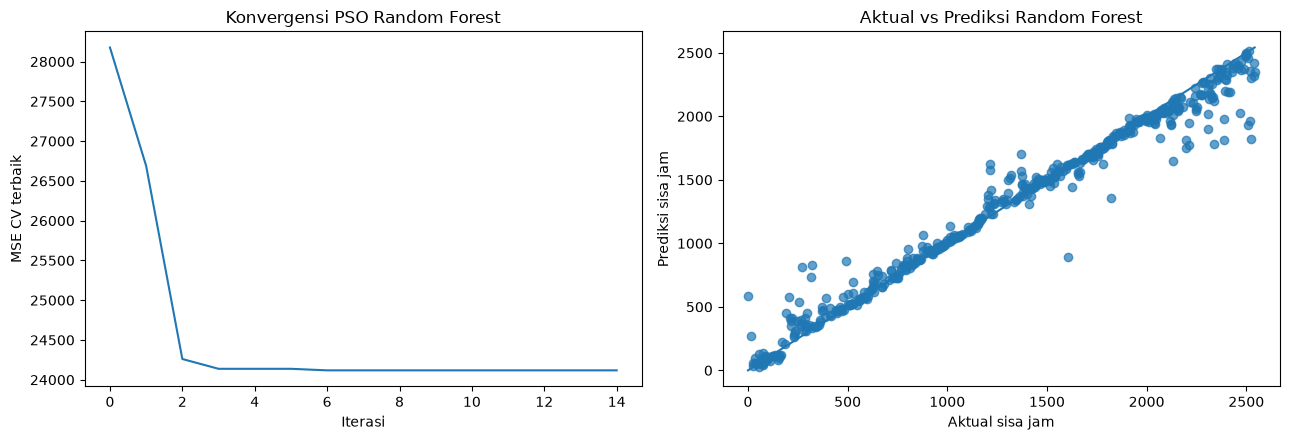

{'optimizer': 'PSO',
 'model': 'Random Forest',
 'data_scope': 'all_status',
 'feature_scope': 'sensor_only',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'break_hour': 78637.0,
 'best_params': {'n_estimators': 217,
  'max_depth': 30,
  'min_samples_split': 2,
  'min_samples_leaf': 1,
  'max_features': 0.7499997621938563},
 'cv_mse': 24118.341580778444,
 'cv_rmse': 155.30080998107655,
 'test_mse': 16012.659040340286,
 'test_rmse': 126.54113576359383,
 'test_mae': 66.96724882999517,
 'test_r2': 0.9696449923006963,
 'status_counts': {'normal': 1847, 'critical': 720, 'break': 1},
 'test_metrics_by_status': {'break': {'rows': 1,
   'rmse': 587.3548387096774,
   'mae': 587.3548387096774,
   'r2': None},
  'critical': {'ro

In [5]:
print("=== Mulai optimasi PSO Random Forest ===", flush=True)
rf_start = time.perf_counter()
rf_obj = make_objective("rf")
rf_pos, rf_score, rf_history, rf_evals = run_pso(
    rf_obj, RF_BOUNDS, cfg["swarm_size"], cfg["iterations"],
    cfg["patience"], cfg["inertia"], cfg["cognitive"], cfg["social"],
    SEED, "Random Forest"
)
rf_result = evaluate(
    "rf", decode_rf(rf_pos), rf_score, rf_history,
    time.perf_counter() - rf_start, rf_evals
)
rf_result

## Optimasi SVR

=== Mulai optimasi PSO SVR ===
[SVR] Inisialisasi selesai | MSE CV terbaik: 14755.019011
[SVR] Iterasi 1/30 | MSE CV terbaik: 13751.068309 | Waktu: 36.0 detik
[SVR] Iterasi 2/30 | MSE CV terbaik: 13362.783647 | Waktu: 65.1 detik
[SVR] Iterasi 3/30 | MSE CV terbaik: 13361.817744 | Waktu: 107.6 detik
[SVR] Iterasi 4/30 | MSE CV terbaik: 13361.817744 | Waktu: 150.7 detik
[SVR] Iterasi 5/30 | MSE CV terbaik: 13361.360493 | Waktu: 200.4 detik
[SVR] Iterasi 6/30 | MSE CV terbaik: 13361.360493 | Waktu: 247.7 detik
[SVR] Iterasi 7/30 | MSE CV terbaik: 13361.356165 | Waktu: 296.5 detik
[SVR] Iterasi 8/30 | MSE CV terbaik: 13361.356165 | Waktu: 346.7 detik
[SVR] Iterasi 9/30 | MSE CV terbaik: 13361.356165 | Waktu: 398.3 detik
[SVR] Iterasi 10/30 | MSE CV terbaik: 13361.356165 | Waktu: 450.6 detik
[SVR] Iterasi 11/30 | MSE CV terbaik: 13361.356165 | Waktu: 501.9 detik
[SVR] Iterasi 12/30 | MSE CV terbaik: 13361.356165 | Waktu: 551.0 detik
[SVR] Iterasi 13/30 | MSE CV terbaik: 13361.356165 | Waktu

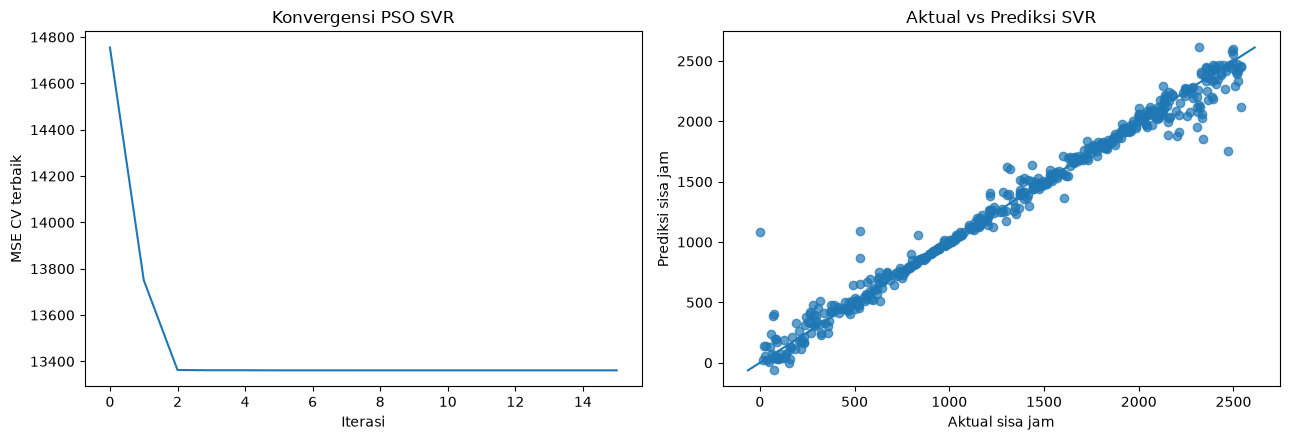

{'optimizer': 'PSO',
 'model': 'SVR',
 'data_scope': 'all_status',
 'feature_scope': 'sensor_only',
 'target': 'sisa jam',
 'features': ['Exhaust Gas Temperature LF (Left Front)',
  'Exhaust Gas Temperature LR (Left Rear)',
  'Exhaust Gas Temperature RF (Right Front)',
  'Exhaust Gas Temperature RR (Right Rear)',
  'Blowby Pressure (Kpa)',
  'Boost Pressure (Kpa)',
  'Engine Oil Temp (°C)',
  'Coolant Temp (°C)'],
 'break_hour': 78637.0,
 'best_params': {'C': 1000.0,
  'epsilon': 0.001,
  'gamma': 0.4011804350173628,
  'kernel': 'rbf'},
 'cv_mse': 13361.356165129753,
 'cv_rmse': 115.59133256922749,
 'test_mse': 11163.182932941743,
 'test_rmse': 105.65596496621355,
 'test_mae': 57.39415985595888,
 'test_r2': 0.9788380866023247,
 'status_counts': {'normal': 1847, 'critical': 720, 'break': 1},
 'test_metrics_by_status': {'break': {'rows': 1,
   'rmse': 1080.6043149708967,
   'mae': 1080.6043149708967,
   'r2': None},
  'critical': {'rows': 163,
   'rmse': 81.50388567036624,
   'mae': 55.0

In [6]:
print("=== Mulai optimasi PSO SVR ===", flush=True)
svr_start = time.perf_counter()
svr_obj = make_objective("svr")
svr_pos, svr_score, svr_history, svr_evals = run_pso(
    svr_obj, SVR_BOUNDS, cfg["swarm_size"], cfg["iterations"],
    cfg["patience"], cfg["inertia"], cfg["cognitive"], cfg["social"],
    SEED + 1, "SVR"
)
svr_result = evaluate(
    "svr", decode_svr(svr_pos), svr_score, svr_history,
    time.perf_counter() - svr_start, svr_evals
)
svr_result

## Perbandingan hasil yang tersedia

In [7]:
results = {}
for kind in ["rf", "svr"]:
    path = out_dir / f"pso_{kind}" / "metrics.json"
    if path.exists():
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("data_scope") == "all_status" and item.get("feature_scope") == "sensor_only":
            results[kind] = item
if not results:
    raise FileNotFoundError("Belum ada hasil PSO sensor-only untuk seluruh status. Jalankan minimal salah satu cell optimasi.")
pd.DataFrame(results).T[["cv_rmse", "test_rmse", "test_mae", "test_r2", "objective_evaluations"]]

,cv_rmse,test_rmse,test_mae,test_r2,objective_evaluations
rf,155.30081,126.541136,66.967249,0.969645,299
svr,115.591333,105.655965,57.39416,0.978838,320
